In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats 


In [18]:

url = "https://drive.google.com/uc?id=1VX-LFyvlpQf7T_6lMnco0DKn6-5PtA1q"
df = pd.read_csv(url)
print(df.head())


   CustomerID  Gender Region  PurchaseAmount ProductCategory Churn  \
0        1001    Male  South          256.07         Fashion    No   
1        1002  Female  South             NaN     Electronics   Yes   
2        1003  Female   West         1194.41         Fashion    No   
3        1004  Female  South          413.06         Grocery    No   
4        1005    Male   West         1556.32         Fashion   Yes   

  CampaignGroup  
0             A  
1             B  
2             A  
3             A  
4             A  


In [2]:
mean_val = df['PurchaseAmount'].mean()
median_val = df['PurchaseAmount'].median()
mode_val = df['PurchaseAmount'].mode()[0]

print("Mean:", mean_val, "Median:", median_val, "Mode:", mode_val)


Mean: 1003.9506701030928 Median: 998.0799999999999 Mode: 0.0


In [3]:
Q1 = df['PurchaseAmount'].quantile(0.25)
Q3 = df['PurchaseAmount'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['PurchaseAmount'] < Q1 - 1.5*IQR) | (df['PurchaseAmount'] > Q3 + 1.5*IQR)]
print("Outliers count:", len(outliers))


Outliers count: 15


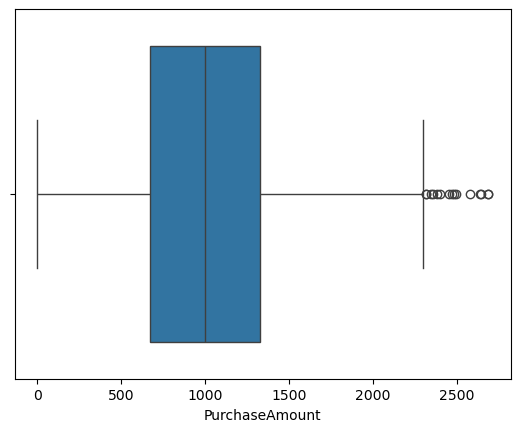

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.boxplot(x=df['PurchaseAmount'])
plt.show()



In [7]:
skewness = df['PurchaseAmount'].skew()
kurtosis = df['PurchaseAmount'].kurt()

print("Skewness:", skewness, "Kurtosis:", kurtosis)


Skewness: 0.10609189374631554 Kurtosis: -0.2615105545319705


In [ ]:
Skewness > 0 → right-skewed

Kurtosis > 3 → heavy tails

In [10]:
from scipy import stats 
male_spend = df[df['Gender']=='Male']['PurchaseAmount']
female_spend = df[df['Gender']=='Female']['PurchaseAmount']

t_stat, p_val = stats.ttest_ind(male_spend, female_spend)
print("t-stat:", t_stat, "p-value:", p_val)


t-stat: nan p-value: nan


In [ ]:
If p_val < 0.05, difference is statistically significant.

In [11]:
churn_table = pd.crosstab(df['ProductCategory'], df['Churn'])
chi2, p, dof, expected = stats.chi2_contingency(churn_table)
print("Chi-square:", chi2, "p-value:", p)


Chi-square: 0.3960436652673918 p-value: 0.8203519424988512


In [ ]:
Significant if p < 0.05.

In [12]:
anova = stats.f_oneway(*[group['PurchaseAmount'].values for name, group in df.groupby('Region')])
print("ANOVA F-stat:", anova.statistic, "p-value:", anova.pvalue)


ANOVA F-stat: nan p-value: nan


In [ ]:
If p < 0.05, spending differs by region.

In [13]:
campaign_means = df.groupby('CampaignGroup')['PurchaseAmount'].mean()
print(campaign_means)


CampaignGroup
A    1011.945587
B     994.339965
Name: PurchaseAmount, dtype: float64


In [ ]:
Higher mean → better performance.

In [14]:
stat, p = stats.shapiro(df['PurchaseAmount'].sample(500))  # sample for speed
print("Shapiro-Wilk p-value:", p)


Shapiro-Wilk p-value: nan


In [ ]:
 If p < 0.05, data is not normal.

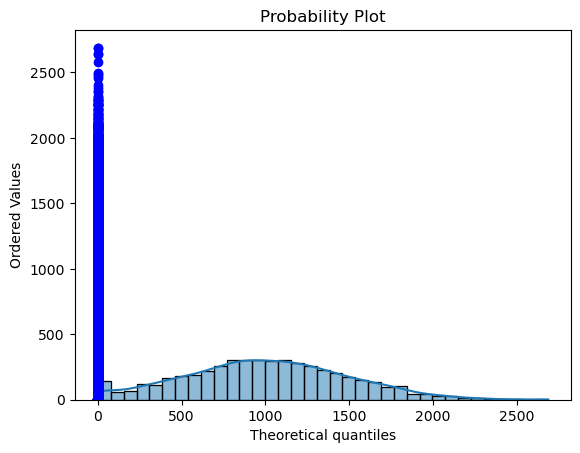

In [15]:
sns.histplot(df['PurchaseAmount'], kde=True)
stats.probplot(df['PurchaseAmount'], dist="norm", plot=plt)
plt.show()


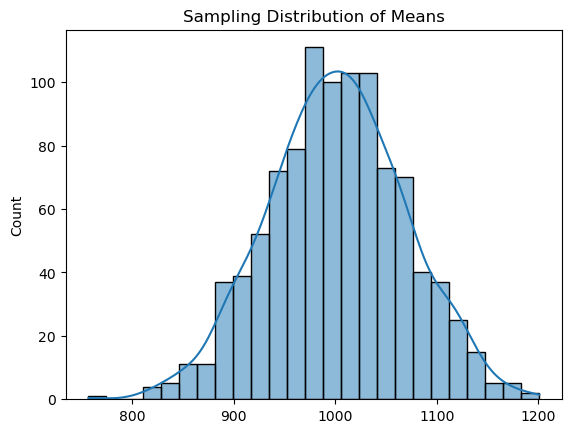

In [16]:
sample_means = [df['PurchaseAmount'].sample(50).mean() for _ in range(1000)]
sns.histplot(sample_means, kde=True)
plt.title("Sampling Distribution of Means")
plt.show()


In [ ]:
Even if PurchaseAmount isn’t normal, the distribution of sample means approaches normal.

In [17]:
mean = df['PurchaseAmount'].mean()
std_err = stats.sem(df['PurchaseAmount'])
ci = stats.t.interval(0.95, len(df['PurchaseAmount'])-1, loc=mean, scale=std_err)

print("95% Confidence Interval:", ci)


95% Confidence Interval: (np.float64(nan), np.float64(nan))
